In [1]:
import numpy as np
import matplotlib.pyplot as plt
from source import ricker,gaussian,gaussian_first_derivative,sine_burst_hann,morlet

Ricker:
$$
s(t)
=\left[1-2\pi^2 f_0^2 (t-t_0)^2\right]\exp\left[-\pi^2 f_0^2 (t-t_0)^2\right]
$$

Gaussian:
$$
s(t)=\exp\left[-\pi^2 f_0^2 (t-t_0)^2\right]
$$

Gaussian first derivative:
$$
s(t)=-2\pi f_0(t-t_0)\exp\left[-\pi^2 f_0^2(t-t_0)^2\right]
$$

Hann-windowed sine burst:
$$T=\frac{N_c}{f_0}$$
$$
s(t)=\begin{cases}\dfrac{1}{2}\left[1-\cos\left(\dfrac{2\pi t}{T}\right)\right]\sin(2\pi f_0t),& 0\le t\le T, \\[8pt]0,& t>T.\end{cases}
$$

Morlet:
$$
s(t)=\exp\left[-\frac{2\pi^2f_0^2(t-t_0)^2}{N_c^2}\right]\cos\left[2\pi f_0(t-t_0)\right]
$$

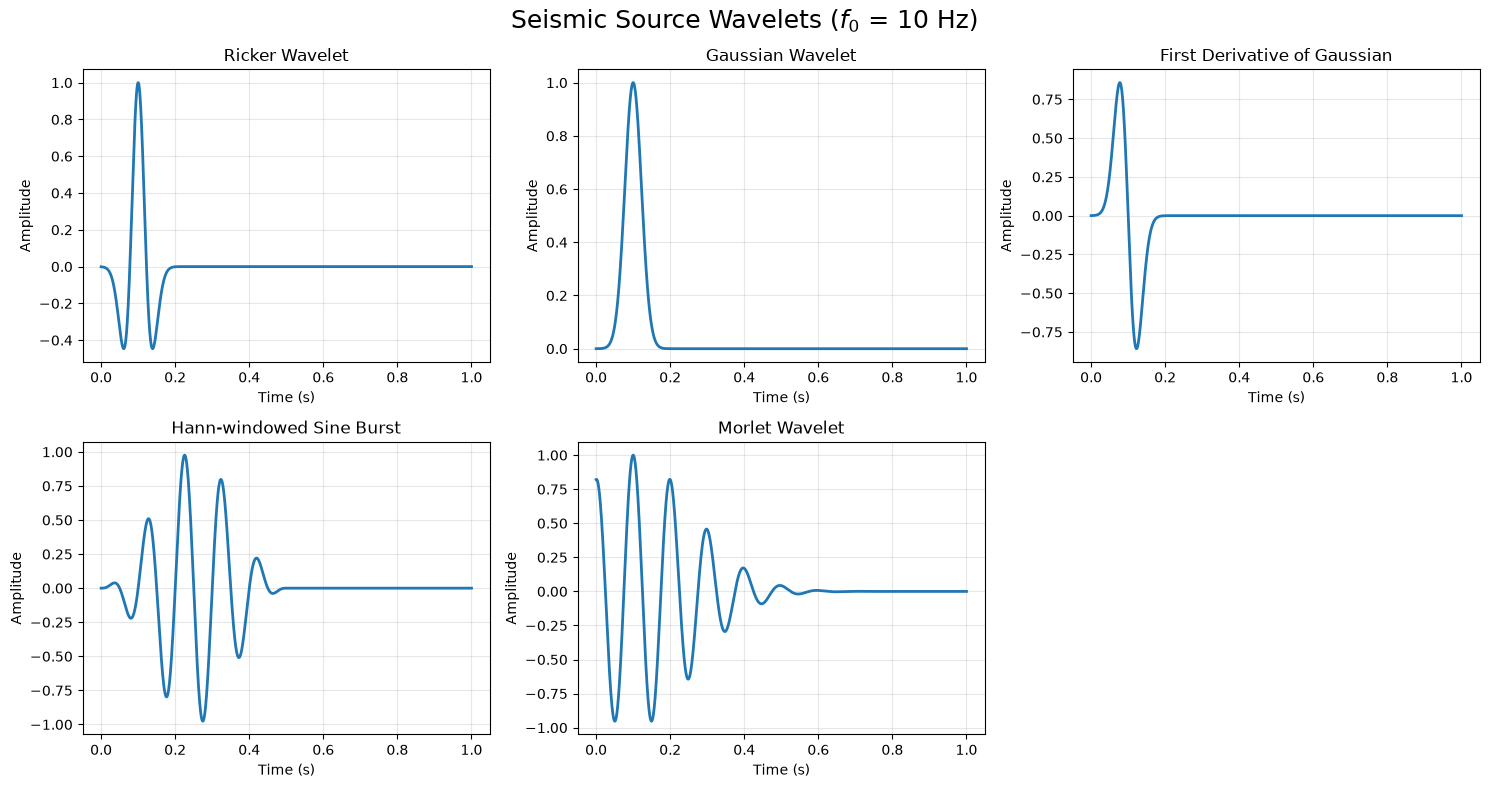

In [2]:
#=============================================
# Seismic source wavelet
#=============================================
# Parameters
dt = 0.0005 # Time interval (s)
t_max = 1 # Total time (s)
t = np.arange(0, t_max + dt, dt)
f0 = 10.0 # Dominant frequency (Hz)
t0 = 1.0 / f0

# Generate wavelets
wavelet_ricker = ricker(t,f0,t0)
wavelet_gaussian = gaussian(t,f0,t0)
wavelet_gaussian_d1 = gaussian_first_derivative(t,f0,t0)
wavelet_sine = sine_burst_hann(t,f0,n_cycles=5)
wavelet_morlet = morlet(t,f0,t0,n_cycles=10)

# Visualization
fig, axes = plt.subplots(2,3,figsize=(15, 8))
# Ricker wavelet
axes[0, 0].plot(t,wavelet_ricker,linewidth=2)
axes[0, 0].set_title('Ricker Wavelet')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(alpha=0.3)

# Gaussian wavelet
axes[0, 1].plot(t,wavelet_gaussian,linewidth=2)
axes[0, 1].set_title('Gaussian Wavelet')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(alpha=0.3)

# First derivative of Gaussian
axes[0, 2].plot(t,wavelet_gaussian_d1,linewidth=2)
axes[0, 2].set_title('First Derivative of Gaussian')
axes[0, 2].set_xlabel('Time (s)')
axes[0, 2].set_ylabel('Amplitude')
axes[0, 2].grid(alpha=0.3)

# Hann-windowed sine burst
axes[1, 0].plot(t,wavelet_sine,linewidth=2)
axes[1, 0].set_title('Hann-windowed Sine Burst')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].grid(alpha=0.3)

# Morlet wavelet
axes[1, 1].plot(t,wavelet_morlet,linewidth=2)
axes[1, 1].set_title('Morlet Wavelet')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].grid(alpha=0.3)

# Turn off the unused subplot
axes[1, 2].axis('off')
# Figure settings
fig.suptitle(
    f'Seismic Source Wavelets ($f_0$ = {f0:.0f} Hz)',
    fontsize=18
)
plt.tight_layout()
plt.show()